In [602]:
from tqdm import tqdm 
import segmentation_models_pytorch as smp
import dataset
import torch
import numpy as np
from matplotlib import pyplot as plt
from importlib import reload
from segmentation_models_pytorch.encoders import get_preprocessing_fn
reload(dataset)

# we take resnet34 as first approach with pretrained weights
model = smp.Unet(encoder_name='resnet34', encoder_weights='imagenet', in_channels=3, classes=1)
preprocess_input = get_preprocessing_fn('resnet34', pretrained='imagenet')

In [603]:
dataset = dataset.load_images(samples=5)

Loading Images


100%|██████████| 5/5 [00:00<00:00, 42.27it/s]


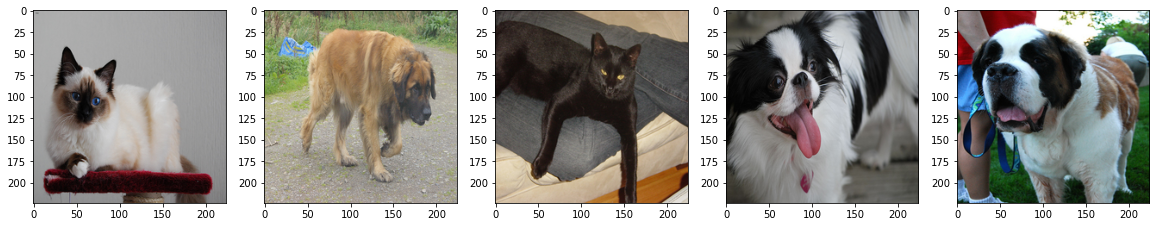

In [604]:
# test the prediction of a single image
resized_data = dataset
_, ax = plt.subplots(1, 5, figsize=(20,20))
for i, axis in enumerate(ax):
    axis.imshow(resized_data[i])
plt.show()

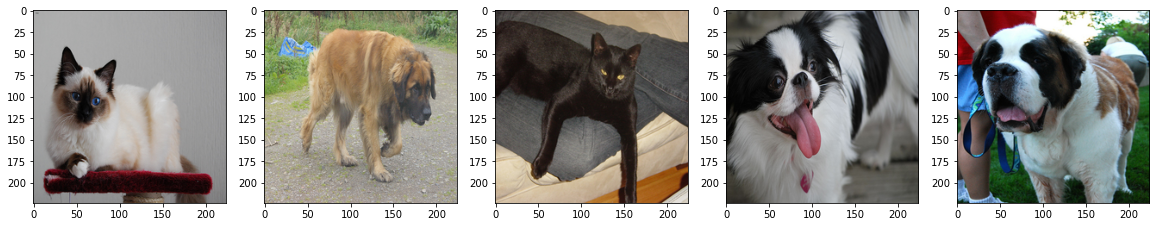

torch.Size([5, 224, 224, 3])
torch.Size([5, 3, 224, 224])


In [605]:
processed_data = preprocess_input(resized_data)

_, ax = plt.subplots(1, 5, figsize=(20,20))
for i, axis in enumerate(ax):
    axis.imshow(processed_data[i], cmap="gray")
plt.show()

print(processed_data.shape)
processed_data = torch.transpose(processed_data, 1, 3)
processed_data = torch.transpose(processed_data, 2, 3)
print(processed_data.shape)

In [606]:
with torch.no_grad():
    logits = model(processed_data.float())
pr_masks = logits.sigmoid()
pr_masks = np.transpose(pr_masks,(0, 2, 3, 1))

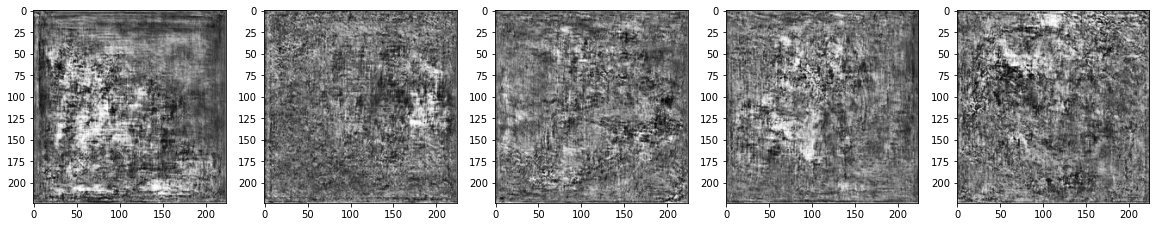

In [609]:
_, ax = plt.subplots(1, 5, figsize=(20,20))
for i, axis in enumerate(ax):
    axis.imshow(pr_masks[i], cmap="gray")
plt.show()
